# Pedestrian Collision Severity in London: Does Greenspace Accessibility Matter Beyond Collision and Casualty Factors?

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

Pedestrian road safety is a urban policy and health challenge. Road collision events are found to be an interplay between human behaviour, vehicle characteristics, environmental conditions and the characteristics of the infrastructure (Hossain et al., 2026). Under complex urban contexts like London, pedestrians are the most vulnerable, facing disproportionately more severe injury outcomes in comparison to other road users (Pour-Rouholamin and Zhou, 2016). The World Health Organization (2023) reported that more than half of global road traffic fatalities involve vulnerable road users, highlighting the urge of understanding and addressing the challenge. Walking is also a fundamental mode of transport within the built environment, delivering benefits for urban health, community, and environmental sustainability (Mayor of London and Transport for London, n.d.). Pedestrian collisions, as a leading cause of deaths and serious injuries, therefore, make the factors shaping pedestrian injury severity an important policy concern.

This is relevant in London, where road safety and urban greening are both central policy objectives. The Mayor of London aims for promoting "Green Transport" and a "Vision Zero" in eliminating all deaths and serious injuries from road collisions by 2041, targeting safer streets, safer speeds and the transformation of dangerous junctions (Mayor of London and Transport for London, n.d.; Transport for London, n.d.). On the other hand, the London Plan 2021 policies G1, G3 and G4 recognised green infrastructure as a facilitator for walking opportunities and urban health, while the Green Transport strategy further positions urban greening as an incentive to making walking more attractive (Mayor of London, 2021). Despite strong policy commitments links, whether proximity to greenspace shapes pedestrian collision outcomes beyond widely recognised traffic and casualty factors remains underexplored.

While existing literature identifies pedestrian demographics, vehicle type and manoeuvre, road conditions, environmental aspects, and junction characteristics as the primary determinants of collision severity, less attention has been paid to whether greenspace accessibility adds explanatory value (Clifton, Burnier and Akar, 2009; Elalouf, Birfir and Rosenbloom, 2023). While policy links greenspace to increased pedestrian activity and walking attractiveness, whether the collision environments near greenspace access points associated with more severe pedestrian injury outcomes beyond the road and vehicle characteristics remains underexplored.

Pedestrian safety is a major urban policy and public health concern because severe pedestrian injuries reflect not only traffic conditions, but also the interaction between urban design, pedestrian behaviour, environmental context, and neighbourhood characteristics. Therefore, this analysis aims to address the gap by examining London pedestrian road safety data for 2024, testing whether proximity to urban greenspace contributes to fatal or serious injury outcomes after accounting for casualty, collision and vehicle factors. A better understanding of factors is fundamental to implement appropriate policy strategies toward a safer and greener London (Pour-Rouholamin and Zhou, 2016).

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

This study will focus on pedestrian collisions in London and examine whether urban greenspace accessibility contributes meaningful explanatory value beyond collision and casualty factors. Therefore, the analysis aims to answer the following research questions:

**RQ1** - Which factors most influences most in the prediction of fatal or serious pedestrian injuries in London in 2024?

**RQ2** - Does proximity to urban greenspace access points add meaningful explanatory power for predicting pedestrian injury severity, after accounting for casualty, collision, and road environment characteristics?

## 3. Data

[[ go back to the top ]](#Table-of-contents)

### 3.1. Load Packages

In [1]:
# Packages to install first prior to loading packages
# %pip install shap

In [2]:
# Data Wrangling
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Spatial Analysis
from libpysal import weights
from esda.moran import Moran, Moran_Local
import matplotlib.patches as mpatches

# Data Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelling
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Model Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, PrecisionRecallDisplay)

# Model Interpretation
import shap
from sklearn.inspection import PartialDependenceDisplay

# Plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### 3.2. Data Loading

In [3]:
# Load Collision 2024
collision = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-collision-2024.csv", low_memory=False)

# Load Casualty 2024 
casualty = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-casualty-2024.csv", low_memory=False)

# Load Vehicle 2024 
vehicle = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-vehicle-2024.csv", low_memory=False)

# Load Green Space data
greenspace = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/OS-Open-Greenspace-GB/GB_AccessPoint.shp")

# Load London LOSA boundary data
london_lsoa = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp")

# Load Lower layer Super Output Area population estimates data
london_lsoa_pop = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/lsoa_pop_london_2024.csv", low_memory=False)
# The above file was pre-loaded and pre-filtered for analysis needs as original file size exceed github 50MB limits 
# Pre-loaded and pre-filtered code:
# lsoa_pop = pd.read_excel(
#     'sapelsoasyoa20222024.xlsx',
#     sheet_name='Mid-2024 LSOA 2021',
#     skiprows=4
# )
# # Extract needed data and saved as CSV
# pop = lsoa_pop.iloc[:, [2, 4]].copy()
# pop.columns = ['LSOA11CD', 'population']
# pop_london = pop[pop['LSOA11CD'].str.startswith('E01')].copy()
# pop_london.to_csv('lsoa_pop_london_2024.csv', index=False)

# Standardise column names
collision.columns = collision.columns.str.strip().str.lower()
casualty.columns = casualty.columns.str.strip().str.lower()
vehicle.columns = vehicle.columns.str.strip().str.lower()
greenspace.columns = greenspace.columns.str.strip().str.lower()

In [4]:
# # Data Inspection

# # Inspect number of rows and columns for all dataset
# print("Collision data shape:", collision.shape)
# print("Casualty data shape:", casualty.shape)
# print("Vehicle data shape:", vehicle.shape)
# print("Greenspace data shape:", greenspace.shape)
# print("London LSOA shape:", london_lsoa.shape)

# # Inspect CRS for greenspace and London boundary data
# print("\nGreenspace CRS:", greenspace.crs)
# print("London LSOA CRS:", london_lsoa.crs)

# # Inspect column names for all dataset
# print("\nCollision Column names:")
# print(collision.columns.tolist())
# print("\nCasualty Column names:")
# print(casualty.columns.tolist())
# print("\nVehicle Column names:")
# print(vehicle.columns.tolist())
# print("\nGreenspace Column names:")
# print(greenspace.columns.tolist())

### 3.3. Data Pre-processing

#### 3.3.1. Data Cleaning 

In [5]:
# Filter to London collisions only
collision_london = collision[
    collision['local_authority_ons_district'].astype(str).str.startswith('E09')
].copy()

# print("London collisions shape:", collision_london.shape)
# print(collision_london['local_authority_ons_district'].nunique())

In [6]:
# Filter Greenspace data to London only
# Using london_lsoa dataset to set london boundary
london_boundary = london_lsoa.dissolve()
# Ensure consistent CRS
greenspace = greenspace.to_crs(london_boundary.crs)
# Clip greenspace to the exact London boundary
greenspace_london = gpd.clip(greenspace, london_boundary)


# Transform geometry column's point(x y z) into normal point(x y) only
# Code derived from LLM (Claude AI)
greenspace_london['geometry'] = greenspace_london['geometry'].apply(
    lambda g: Point(g.x, g.y)  # drops Z, keeps X and Y only
)

# Create collision points for calculating nearest greenspace distance
collision_points = gpd.GeoDataFrame(
    # remove duplicated collision_index
    collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index'),
    # convert lat and long to geometry
    geometry=gpd.points_from_xy(
        collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index')['longitude'],
        collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index')['latitude']
    ),
    crs='EPSG:4326'
).to_crs('EPSG:27700')

# Nearest greenspace access point
collision_green_nearest = gpd.sjoin_nearest(
    collision_points,
    greenspace_london[['geometry']],
    how='left',
    distance_col='dist_to_greenspace_m'
)[['collision_index', 'dist_to_greenspace_m']].drop_duplicates('collision_index')

# Merge newly computed collisioin to nearest greenspace a.p. with london collision
collision_london = collision_london.merge(
    collision_green_nearest,
    on='collision_index',
    how='left'
)

In [7]:
# Filter to Pedestrian casualties only
# 3 = Pedestrians
casualty_ped = casualty[casualty['casualty_class'] == 3].copy()

In [8]:
# Filter for London Pedestrian casualties only
casualty_ped_london = casualty_ped[
    casualty_ped['collision_index'].isin(collision_london['collision_index'])
].copy()

In [9]:
# Check how many collision have more than one pedestrian casualty
peds_per_collision = casualty_ped_london.groupby('collision_index').size()

print("Number of pedestrian-collision rows:", len(casualty_ped_london))
print("Number of unique collisions involving pedestrians:", casualty_ped_london['collision_index'].nunique())
print("Number of collisions with >1 pedestrian casualty:", (peds_per_collision > 1).sum())
print("Maximum pedestrians in a single collision:", peds_per_collision.max())

Number of pedestrian-collision rows: 4445
Number of unique collisions involving pedestrians: 4299
Number of collisions with >1 pedestrian casualty: 127
Maximum pedestrians in a single collision: 4


#### 3.3.2. Data Merge / Joins

In [10]:
# Merge casualty, collision, and vehicle data
df_merge = (
    # Merge pedestrian casualties
    casualty_ped_london
    .merge(
        # with London collisions
        collision_london.drop(columns=['collision_year', 'collision_ref_no'], errors='ignore'),
        on='collision_index',
        how='left'
    )
    .merge(
        # with vehicles
        vehicle.drop(columns=['collision_year', 'collision_ref_no'], errors='ignore'),
        on=['collision_index', 'vehicle_reference'],
        how='left'
    )
)

In [11]:
# # Check variables after merge
# print(df_merge.columns.tolist())

### 3.4. Data Wrangling

#### 3.4.1. Data Ambiguity

In [12]:
# # Check ambiguity of potentially needed variables
# ambiguous_codes = {
#     # casualty (pedestrian data)
#     'sex_of_casualty':          [-1, 9],
#     'age_of_casualty':          [-1],
#     'pedestrian_location':      [-1, 10],
#     'pedestrian_movement':      [-1, 9],
#     'pedestrian_road_maintenance_worker': [-1, 2], # also a type of pedestrian so include it
#     'casualty_imd_decile':      [-1],

#     # collision / road environment
#     'speed_limit':              [-1, 99],
#     'first_road_class':         [-1],
#     'road_type':                [-1, 9],
#     'junction_detail':          [-1, 99],
#     'junction_control':         [-1, 9],
#     'pedestrian_crossing':      [-1, 99],
#     'light_conditions':         [-1],
#     'weather_conditions':       [-1, 9],
#     'road_surface_conditions':  [-1, 9],
#     'urban_or_rural_area':      [-1],
#     'trunk_road_flag':          [-1],

#     # vehicle / driver
#     'vehicle_type':             [-1, 99],
#     'vehicle_manoeuvre':        [-1, 99],
#     'junction_location':        [-1, 9],
#     'sex_of_driver':            [-1, 3],
#     'age_of_driver':            [-1],
#     'driver_imd_decile':        [-1],
#     'engine_capacity_cc':       [-1],
#     'age_of_vehicle':           [-1]
# }

# # Print a summary table of unknown missing values
# inspection_rows = []
# for col, codes in ambiguous_codes.items():
#     if col not in df_merge.columns:
#         continue
    
#     total= len(df_merge)
#     actual_nan= df_merge[col].isnull().sum()
#     ambig_count= df_merge[col].isin(codes).sum()
#     total_missing= actual_nan + ambig_count
#     pct= total_missing / total * 100
#     inspection_rows.append({
#         'variable': col,
#         'total_rows': total,
#         'actual_NaN': actual_nan,
#         'ambiguous_codes': str(codes),
#         'ambiguous_count': ambig_count,
#         'total_missing': total_missing,
#         'pct_missing': round(pct, 1)
#     })

# inspection_df = pd.DataFrame(inspection_rows).sort_values('pct_missing', ascending=False)
# print("Missing / Unknown Data Inspection:")
# print(inspection_df.to_string(index=False))

|Variable|Code|Code Interpretation|Action|
|---|---|---|---|
|pedestrian_movement|-1, 9|Missing / unknown or other|Recode to `NaN`, impute with categorical `Missing`|
|junction_control|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|vehicle_manoeuvre|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|junction_location|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|casualty_imd_decile|-1|Missing|Recode to `NaN`, impute with categorical `Missing`|
|pedestrian_location|-1, 10|Missing / unknown or other|Recode to `NaN`, impute with categorical `Missing`|
|junction_detail|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|road_type|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|pedestrian_crossing|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|weather_conditions|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`, keep `8 = Other`|
|road_surface_conditions|-1, 9|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|age_of_casualty|-1|Missing|Recode to `NaN`, impute with median|
|vehicle_type|-1, 99|Missing / unknown vehicle type|Recode to `NaN`, impute with categorical `Missing`, keep `90 = Other vehicle`|
|pedestrian_road_maintenance_worker|-1, 2|Missing / not known|Recode to `NaN`, impute with categorical `Missing`|
|sex_of_casualty|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|speed_limit|-1, 99|Missing / unknown|No action needed |
|first_road_class|-1, 9|Missing / unknown|No action needed|
|light_conditions|-1|Missing|No action needed |
|urban_or_rural_area|-1|Missing|No action needed |
|trunk_road_flag|-1|Missing|No action needed |
|driver_imd_decile|-1|Missing|Exclude from modelling due to high levels of missing data|
|sex_of_driver|-1, 3|Missing / not known|Exclude from modelling due to high levels of missing data|
|age_of_driver|-1|Missing|Exclude from modelling due to high levels of missing data|
|engine_capacity_cc|-1|Missing|Exclude from modelling due to high levels of missing data|
|age_of_vehicle|-1|Missing|Exclude from modelling due to high levels of missing data|

#### 3.4.2. Data Ambiguity Recode

In [13]:
# Variable that needs recoding
recode_nan = {
    # collision
    'junction_control': [-1, 9],
    'junction_detail': [-1, 99],
    'road_type': [-1, 9],
    'pedestrian_crossing': [-1, 99],
    'weather_conditions': [-1, 9],
    'road_surface_conditions': [-1, 9],

    # casualty
    'pedestrian_movement': [-1, 9],
    'casualty_imd_decile': [-1],
    'pedestrian_location': [-1, 10],
    'age_of_casualty': [-1],
    'pedestrian_road_maintenance_worker': [-1, 2], 
    'sex_of_casualty': [-1, 9],

    # vehicle
    'vehicle_manoeuvre': [-1, 99],
    'junction_location': [-1, 9],
    'vehicle_type': [-1, 99] # keep 90 = Others
}

In [14]:
# Set recode function
def apply_recode(df, recode_dict):
    df = df.copy()
    for col, bad_codes in recode_dict.items():
        if col in df.columns:
            df[col] = df[col].replace(bad_codes, np.nan)
    return df

In [15]:
# Apply recode functions to the merged dataset
df_merge_recode = apply_recode(df_merge, recode_nan)

In [16]:
# # Check merged columns 
# print("\n Merged Dataframe Columns:")
# print(df_merge_recode.columns.tolist())

#### 3.4.3. Data Filtering and Data Types
##### Data Filtering

In [17]:
# Select needed columns
selected_columns = [
    # To be used to create our target binary variable
    'casualty_severity',

    # casualty, pedestrian variables
    'sex_of_casualty',
    'age_of_casualty',
    'pedestrian_location',
    'pedestrian_movement',
    'pedestrian_road_maintenance_worker',
    'casualty_imd_decile',
    'lsoa_of_accident_location', # for mapping purposes

    # collision, road and environment variables
    'speed_limit',
    'first_road_class',
    'road_type',
    'junction_detail',
    'junction_control',
    'pedestrian_crossing',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'trunk_road_flag',

    # vehicle, driver variables
    'vehicle_type',
    'vehicle_manoeuvre',
    'junction_location',
    # 'sex_of_driver', # Excluded for high levels missing data
    # 'age_of_driver', # Excluded for high levels missing data
    # 'age_of_vehicle', # Excluded for high levels missing data
    # 'driver_imd_decile', # Excluded for high levels missing data

     # spatial contextual variable
    'dist_to_greenspace_m'
]

selected_columns = [c for c in selected_columns if c in df_merge_recode.columns]

df_clean = df_merge_recode[selected_columns].copy()

##### Data Types

In [18]:
# Define features by data type and datasets groups

casualty_numeric = ['age_of_casualty']
casualty_categorical = [
    'sex_of_casualty', 'pedestrian_location', 'pedestrian_movement',
    'pedestrian_road_maintenance_worker', 'casualty_imd_decile']

# No numeric features for raod
road_categorical = [
    'speed_limit', 'first_road_class', 'road_type', 'junction_detail',
    'junction_control', 'pedestrian_crossing', 'light_conditions',
    'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'trunk_road_flag'
]

# No numeric features for vehicle
vehicle_categorical = ['vehicle_type', 'vehicle_manoeuvre', 'junction_location']

# No numeric features for greenspace
greenspace_numeric = ['dist_to_greenspace_m']

# All features in numeric and categorical
numeric_features = casualty_numeric + greenspace_numeric
categorical_features = casualty_categorical + road_categorical + vehicle_categorical

# Note* 
# severity_levels are targets so not included here
# casualty_severity used to create severity levels so not included here
# longitude and latitude not included here
# lsoa_of_accident_location not included here

In [19]:
# Assign categroical features as objects (aka categories make them not comparable numbers)

# Numeric columns
# Keep values as numeric
for col in numeric_features:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Categorical columns
# Convert all non-missing values to strings --> keep missing as NaN
for col in categorical_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(lambda x: np.nan if pd.isna(x) else str(x))

# Check numeric features are numeric
print("\nNumeric Features:")
print(df_clean[numeric_features].dtypes)

# Check categorical features are strings
print("\nCategorical Features:")
print(df_clean[categorical_features].dtypes)

# Check NaN is preserved correctly (not converted to string "nan")
print("\nNaNs:")
print(df_clean[categorical_features].isnull().sum()[df_clean[categorical_features].isnull().sum() > 0])


Numeric Features:
age_of_casualty         float64
dist_to_greenspace_m    float64
dtype: object

Categorical Features:
sex_of_casualty                       object
pedestrian_location                   object
pedestrian_movement                   object
pedestrian_road_maintenance_worker    object
casualty_imd_decile                   object
speed_limit                           object
first_road_class                      object
road_type                             object
junction_detail                       object
junction_control                      object
pedestrian_crossing                   object
light_conditions                      object
weather_conditions                    object
road_surface_conditions               object
urban_or_rural_area                   object
trunk_road_flag                       object
vehicle_type                          object
vehicle_manoeuvre                     object
junction_location                     object
dtype: object

NaNs:
sex_

#### 3.4.4. Target Variable 
The `severity_levels` variable is defined as:

- **1 = fatal or serious pedestrian injury outcome**
- **0 = slight pedestrian injury outcome**

The target variable was derived from casualty_severity as a binary outcome fatal and serious injuries were coded as 1, while slight injuries were coded as 0. Fatal and serious outcomes were grouped because fatal cases alone were too rare to support stable modelling, and because both categories represent the severe-injury outcome most relevant to road safety policy.

Fatal and serious cases were grouped to address class imbalance and to reflect the policy relevance of severe outcomes.


- to solve class imbalance issues as fatal cases are very little

In [20]:
# Check initial distribution of casualty severity categories
print("Casualty severity data distribution:")
print(df_clean['casualty_severity'].value_counts())

# Create a binary for our target (severity levels)
df_clean['severity_levels'] = np.where(df_clean['casualty_severity'].isin([1, 2]), 1, 0)
print("\nCasualty severity groupped binary:")
print(df_clean['severity_levels'].value_counts())

Casualty severity data distribution:
casualty_severity
3    3249
2    1135
1      61
Name: count, dtype: int64

Casualty severity groupped binary:
severity_levels
0    3249
1    1196
Name: count, dtype: int64


In [21]:
# Check data types in df_clean
print("\n df_clean data types:")
print(df_clean.dtypes)


 df_clean data types:
casualty_severity                       int64
sex_of_casualty                        object
age_of_casualty                       float64
pedestrian_location                    object
pedestrian_movement                    object
pedestrian_road_maintenance_worker     object
casualty_imd_decile                    object
lsoa_of_accident_location              object
speed_limit                            object
first_road_class                       object
road_type                              object
junction_detail                        object
junction_control                       object
pedestrian_crossing                    object
light_conditions                       object
weather_conditions                     object
road_surface_conditions                object
urban_or_rural_area                    object
trunk_road_flag                        object
vehicle_type                           object
vehicle_manoeuvre                      object
junction_lo

#### 3.4.5. Variable Confounding Inspection
Prior to modelling, a potential confounding relationship between distance to the nearest greenspace access point and road speed limit was examined. Greenspace access points in London are mostly located within residential neighbourhoods with lower speed limits, while higher speed roads tend to pass through corridors with fewer greenspace access points. This urban pattern suggests that any observed association between greenspace proximity and pedestrian injury severity may be partially attributable to the correlated road speed environment rather than greenspace accessibility itself. The Spearman correlation showed a weak statistically significant relationship between the two variables with ρ = 0.124 and p < 0.001, indicating that collisions occurring closer to greenspace tend to have lower speed limits. Therefore, both variables will be included as predictors for tree-based modelling approaches, allowing greenspace accessibility to be modelled after accounting for road speed context.

In [22]:
# Check correlation between greenspace distance and speed limit
greenspace_speedlimit_check = df_clean[['dist_to_greenspace_m', 'speed_limit']].copy()
greenspace_speedlimit_check['speed_limit'] = pd.to_numeric(greenspace_speedlimit_check['speed_limit'], errors='coerce')
greenspace_speedlimit_check = greenspace_speedlimit_check.dropna()

rho, pval = spearmanr(greenspace_speedlimit_check['dist_to_greenspace_m'], greenspace_speedlimit_check['speed_limit'])
print(f"Spearman correlation between greenspace distance and speed limit:")
print(f"ρ = {rho:.4f}, p = {pval:.4f}")

# Also show mean greenspace distance by speed limit
mean_greenspace = (
    df_clean.groupby('speed_limit')['dist_to_greenspace_m']
    .mean()
    .reset_index()
    .sort_values('speed_limit')
)
mean_greenspace['speed_limit'] = pd.to_numeric(mean_greenspace['speed_limit'], errors='coerce')
mean_greenspace = mean_greenspace.dropna().sort_values('speed_limit')
print("\nMean greenspace distance by speed limit:")
print(mean_greenspace.to_string(index=False))

Spearman correlation between greenspace distance and speed limit:
ρ = 0.1235, p = 0.0000

Mean greenspace distance by speed limit:
 speed_limit  dist_to_greenspace_m
          20            150.938074
          30            180.468014
          40            194.532716
          50            199.818479
          60            333.308242
          70            643.755792


### 3.5. Metadata 

The variables information below shows the cleaned dataframe prior to modelling. Additional pre-processing for tree-based methods analysis, including imputation, scaling, and one-hot encoding will be applied within the modelling pipeline and will not affect the data structure.

| Variable | Type | Description | Notes |
|---|---|---|---|
| severity_levels | Binary | Determine pedestrian injury severity levels: 1 = fatal or serious injury, 0 = slight injury | Target variable |
| casualty_severity | Categorical | Recorded casualty severity levels: 1 = fatal, 2 = serious, 3 = slight | Used to create `severity_levels`variable, will be excluded from modelling |
| sex_of_casualty | Categorical | Sex of the pedestrian casualty | Input Predictor |
| age_of_casualty | Numeric | Age of the pedestrian casualty in years | Input Predictor |
| pedestrian_location | Categorical | Pedestrian's location relative to the carriageway or crossing at collision | Input Predictor |
| pedestrian_movement | Categorical | Reported movement of the pedestrian at collision | Input Predictor |
| pedestrian_road_maintenance_worker | Categorical | Record as a road maintenance worker | Input Predictor |
| casualty_imd_decile | Categorical | Index of Multiple Deprivation decile associated with the area of casualty| Input Predictor |
| lsoa_of_accident_location | ID | LSOA code of the collision location | Retained for spatial exploratory analysis purposes, will be excluded from modelling |
| longitude | Numeric | Longitude coordinate of the collision location | Retained in dataframe; excluded from modelling |
| latitude | Numeric | Latitude coordinate of the collision location | Spatial Input Predictor |
| speed_limit | Categorical | Speed limit of the collision location | Input Predictor |
| first_road_class | Categorical | Classification of the first road at the collision location | Input Predictor |
| road_type | Categorical | Type of road where the collision occurred | Input Predictor |
| junction_detail | Categorical | Type of junction at the collision location | Input Predictor |
| junction_control | Categorical | Tyoe of traffic control present at the junction | Input Predictor |
| pedestrian_crossing | Categorical | Type of pedestrian crossing facility present | Input Predictor |
| light_conditions | Categorical | Lighting conditions at collision | Input Predictor |
| weather_conditions | Categorical | Weather conditions at collision | Input Predictor |
| road_surface_conditions | Categorical | Condition of the road surface at the time of collision | Input Predictor |
| urban_or_rural_area | Categorical | Classification of the collision location as urban or rural | Input Predictor |
| trunk_road_flag | Categorical | Indicator of if the collision occurred on a trunk road | Input Predictor |
| vehicle_type | Categorical | Type of vehicle associated with the pedestrian casualty | Input Predictor |
| vehicle_manoeuvre | Categorical | Manoeuvre of the associated vehicle at collision | Input Predictor |
| junction_location | Categorical | Position of the associated vehicle relative to the junction | Input Predictor |
| dist_to_greenspace_m | Numeric | Distance to the nearest greenspace access point in metres | Spatial Input Predictor, typically for answering RQ2 |

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

Machine learning (ML) approaches has been widely adopted in road safety data analysis, as traditional discrete methods depend on pre-specified assumptions and tends to struggle with noisy data. ML benefits from higher flexibility, ability to acquire only minimal prior assumptions, thus demonstrate stronger predictive (Dong et al., 2022; Tao et al., 2022). While ML approaches can establish complex, non-linear relationships between input variables and injury severity outcomes, yet it also face limitations of their black-box nature (Dong et al., 2022). Therefore, this analysis applies two tree-based ensemble models and a Shapley Additive exPlanations (SHAP) to rank feature importance and interpret the optimal model from a global perspective.

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

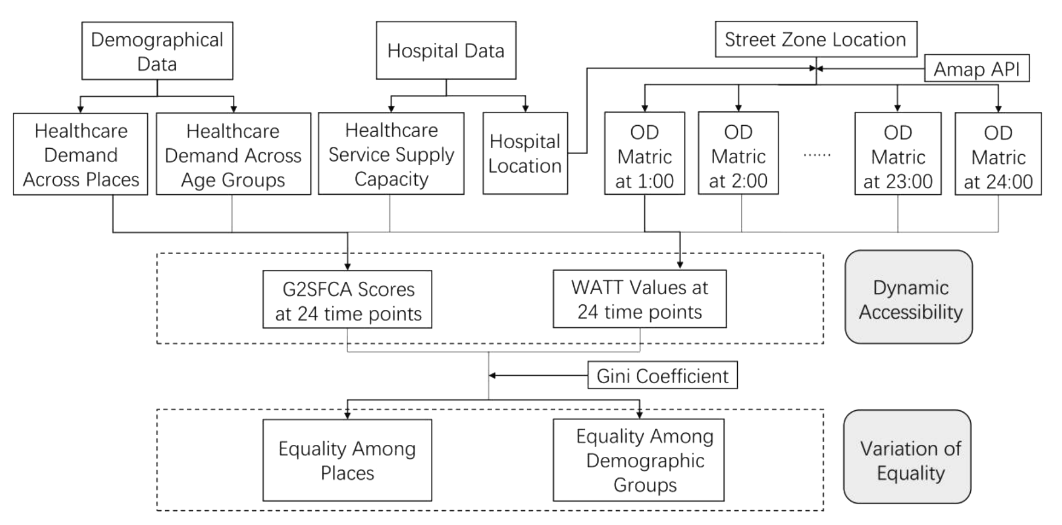

## 5. Results and Discussion

[[ go back to the top ]](#Table-of-contents)

### 5.1. Imputation Pipeline
This section defines pre-processing pipelines to impute missing values to prepare features prior modelling. Numeric variables were imputed using the median and standardised, while categorical variables were imputed with a "Missing" category and one-hot encoded. A ColumnTransformer was used to allow application of different pre-processing workflow to different columns within the machine learning pipeline.

In [23]:
# Define Imputation Pipeline
# Impute as Tree based methods cannot deal with NaNs

# Impute NaN with median
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Impute NaN with 'Missing'
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    # onehot encode for dummy 
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Define column transformer --> to use in methodology later for trees
transformed = ColumnTransformer(
    transformers=[
        # numeric
        ('num', numeric_pipeline, numeric_features),
        # categorical
        ('cat', categorical_pipeline, categorical_features)
    ]
)

### 5.2. Exploratory Data Analysis

#### 5.2.1. Pedestrian Severity Levels Data Distribution

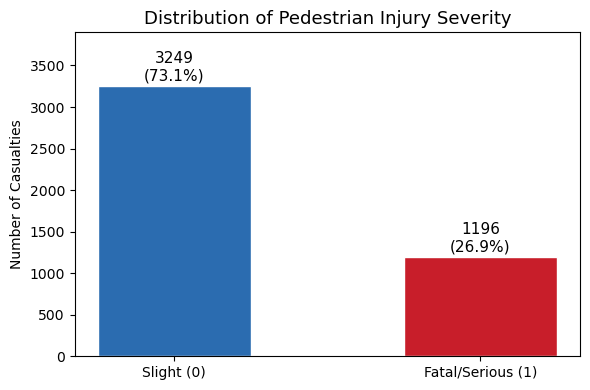

In [24]:
severity_counts = df_clean['severity_levels'].value_counts()
labels = ['Slight (0)', 'Fatal/Serious (1)']
colors = ['#2B6CB0', '#C81E2A']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, severity_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, severity_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{count}\n({count/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Distribution of Pedestrian Injury Severity', fontsize=13)
ax.set_ylabel('Number of Casualties')
ax.set_ylim(0, severity_counts.max() * 1.2)
plt.tight_layout()
plt.show()

#### 5.2.2. Heatmap of Age and Speed Limit on Fatal/ Serious Pedestrian Injury

In [25]:
df_clean.speed_limit.describe()

count     4445
unique       6
top         20
freq      2808
Name: speed_limit, dtype: object

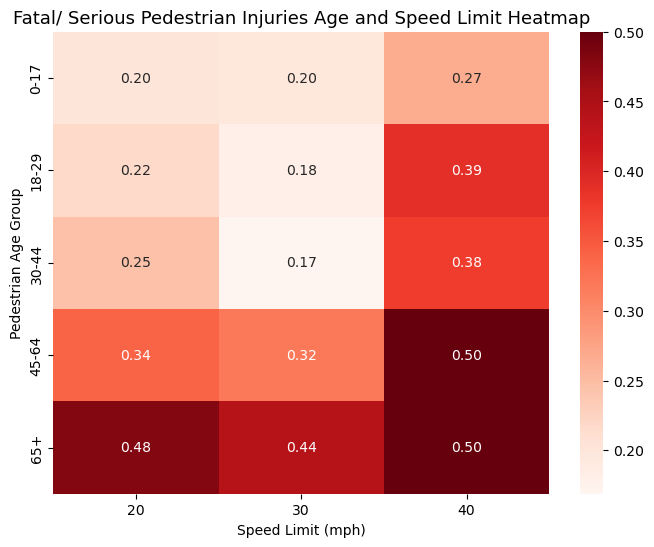

In [28]:
# Ensure speed_limit is numeric
df_clean['speed_limit'] = pd.to_numeric(df_clean['speed_limit'], errors='coerce')

# Select low speed limit 
# As 50, 60 and 70mph roads are for dual carriageways and motorways in the UK (https://www.gov.uk/speed-limits)
target_speeds = [20, 30, 40]
df_filtered = df_clean[df_clean['speed_limit'].isin(target_speeds)].copy()

# Create Age Groups
age_bins = [0, 18, 30, 45, 65, 100]
age_labels = ['0-17', '18-29', '30-44', '45-64', '65+']
df_filtered['age_group'] = pd.cut(
    df_filtered['age_of_casualty'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Pivot data table
pivot_table = df_filtered.pivot_table(
    index='age_group', 
    columns='speed_limit', 
    values='severity_levels', 
    aggfunc='mean'
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='Reds', fmt=".2f")
plt.title("Fatal/ Serious Pedestrian Injuries Age and Speed Limit Heatmap", fontsize=13)
plt.ylabel("Pedestrian Age Group")
plt.xlabel("Speed Limit (mph)")
plt.show()

#### 5.2.3. Spatial Autocorrelation Inspection with Moran's I 
This section aims to inspect whether pedestrian fatal/serious injury severity is randomly distributed across London, or if they exhibit clustering in certain areas in London. 

In [29]:
# Reload LSOA boundary to avoid any clashes with earlier dissolve to london boundaries
london_lsoa_reload = gpd.read_file(
    "https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp"
)
london_lsoa_reload = london_lsoa_reload.to_crs('EPSG:27700')
# Clean any geometry issues
london_lsoa_reload['geometry'] = london_lsoa_reload['geometry'].buffer(0)

# Aggregate severity
lsoa_severity = (
    # Group by LSOA
    df_clean.groupby('lsoa_of_accident_location')['severity_levels']
    # Create new columns of sum up total number of casualties and sum of fatal/ serious
    .agg(total_casualties='count', fatal_serious='sum')
    .reset_index()
    .rename(columns={'lsoa_of_accident_location': 'LSOA11CD'})
)

# Merge data
lsoa_morans = (
    london_lsoa_reload
    .merge(lsoa_severity, on='LSOA11CD', how='left')
    .merge(london_lsoa_pop, on='LSOA11CD', how='left')
)

# Calculate fatal/ serious rate per 10,000 population
# fatal/serious casualty rate = fatal or serious casualties / population × 10,000
# Use 10,000 to allow more interpretability for LSOAs
lsoa_morans['rate_per_10000'] = (
    lsoa_morans['fatal_serious'] / lsoa_morans['population'] * 10_000).round(2)
# Replace LSOAs with NaNs with 0
lsoa_morans['rate_per_10000'] = lsoa_morans['rate_per_10000'].fillna(0)
lsoa_morans = lsoa_morans.reset_index(drop=True)


# Create spatial weights using KNN, 8 nearest neighbours
w = weights.KNN.from_dataframe(lsoa_morans, k=8)
# Row standardise weights --> ensure neighbours add up to 1 for fairness across LSOAs
w.transform = 'r'

# Check data prior doing Moran's I
print(f"Observations : {w.n}")
print(f"LSOAs with no neighbours : {len(w.islands)}")

Observations : 4835
LSOAs with no neighbours : 0


In [32]:
# Moran's I --> test any spatial clustering
moran = Moran(lsoa_morans['rate_per_10000'], w, permutations=999)

print(f"\nGlobal Moran's I Results:")
print(f"Moran's I : {moran.I:.4f}")
# print(f"Expected : {moran.EI:.4f}")
print(f"p-value : {moran.p_sim:.4f}")

# Local Moran's I (LISA) --> test any stat sig local clustering
lisa = Moran_Local(lsoa_morans['rate_per_10000'], w, permutations=999)

sig    = lisa.p_sim < 0.05
labels = np.full(len(lsoa_morans), 'Not Significant', dtype=object)
labels[(lisa.q == 1) & sig] = 'High-High (Hot Spot)'
labels[(lisa.q == 3) & sig] = 'Low-Low (Cold Spot)'
labels[(lisa.q == 2) & sig] = 'Low-High'
labels[(lisa.q == 4) & sig] = 'High-Low'

lsoa_morans['lisa_label'] = labels

print("\nLISA Cluster Summary:")
print(pd.Series(labels).value_counts().to_string())


Global Moran's I Results:
Moran's I : 0.0481
p-value : 0.0010

LISA Cluster Summary:
Not Significant         4539
Low-High                 134
High-Low                 113
High-High (Hot Spot)      49


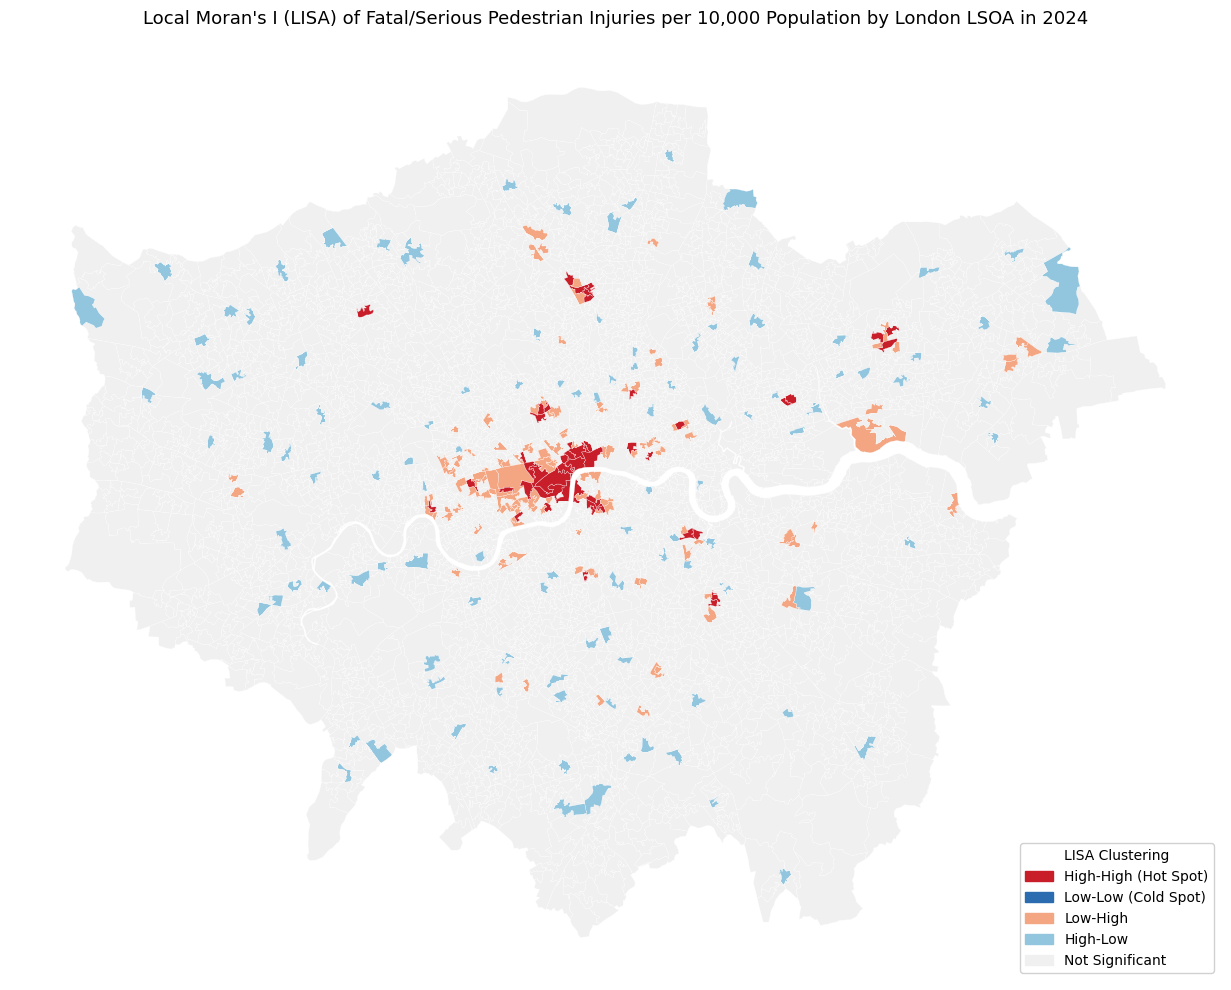

In [33]:
# Plot LISA map
color_map = {
    'High-High (Hot Spot)': '#C81E2A',
    'Low-Low (Cold Spot)': '#2B6CB0',
    'Low-High': '#F4A582',
    'High-Low': '#92C5DE',
    'Not Significant': '#f0f0f0'
}
lsoa_morans['color'] = lsoa_morans['lisa_label'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 10))

lsoa_morans.plot(
    color=lsoa_morans['color'],
    edgecolor='white',
    linewidth=0.2,
    ax=ax
)

patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in color_map.items()
]
ax.legend(
    handles=patches,
    loc='lower right',
    fontsize=10,
    title='LISA Clustering',
    title_fontsize=10,
    framealpha=0.9
)

ax.set_title(
    f"Local Moran's I (LISA) of Fatal/Serious Pedestrian Injuries per 10,000 Population by London LSOA in 2024",
    fontsize=13, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 5.3. Train Test Split 

### 5.4. Decision Tree Baseline Model

### 5.5. Random Forest Models

### 5.6. SHAP Model Interpretation

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

## 7. References

[[ go back to the top ]](#Table-of-contents)